# 01 - Analise Exploratoria de Dados (EDA)

**Dataset:** [House Pricing Dataset](https://www.kaggle.com/datasets/alyelbadry/house-pricing-dataset) (Kaggle) -
vendas de imoveis em King County, WA (regiao de Seattle), entre 2014 e 2015.

**Objetivo deste notebook:** entender a estrutura, qualidade e distribuicao dos dados
brutos ANTES de decidir como limpa-los e modela-los. As decisoes tomadas aqui viram
regras codificadas em `src/house_prices/data/clean.py` e `src/house_prices/features.py`
- este notebook e o "laboratorio", o `src/` e o "codigo de producao" que resulta dele.

Um notebook e otimo para explorar, mas e um artefato fragil (dificil de testar, de
rodar em producao, de revisar em PR). Por isso, uma vez que uma decisao de limpeza ou
feature e validada aqui, ela migra para uma funcao testada em `src/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from house_prices.config import RAW_DATA_PATH

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
df.head()

(21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,Average,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,Average,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,Average,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,Very Good,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,Average,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 1. Estrutura geral: tipos, nulos, duplicatas

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  str    
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  str    
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [3]:
print("Valores nulos por coluna:")
print(df.isnull().sum().sum(), "no total")

print("\nLinhas totalmente duplicadas:", df.duplicated().sum())
print("IDs duplicados (mesmo imovel vendido mais de uma vez):", df["id"].duplicated().sum())

Valores nulos por coluna:
0 no total

Linhas totalmente duplicadas: 0
IDs duplicados (mesmo imovel vendido mais de uma vez): 177


Nao ha valores nulos - otimo, isso simplifica a limpeza (nao precisamos de
estrategia de imputacao). Porem ha **177 ids duplicados**: o dataset registra cada
*venda*, e alguns imoveis foram vendidos mais de uma vez no periodo coberto. Se nao
tratarmos isso, o mesmo imovel pode acabar no treino E no teste ao mesmo tempo -
vazamento de dados (data leakage) que infla a metrica de avaliacao de forma
enganosa. Decisao: manter so a venda mais recente de cada `id` (feito em
`clean_data`).

## 2. Variavel alvo: `price`

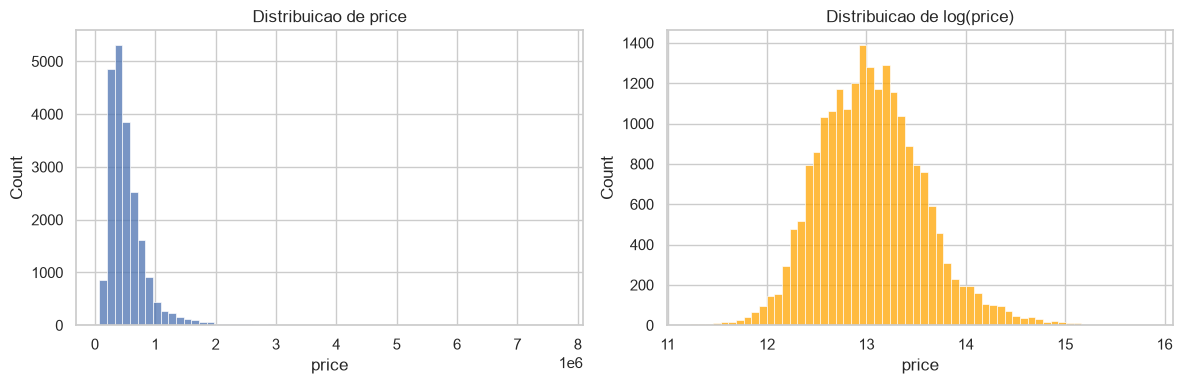

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [ ]:
# Mostra a distribuição da variável price e a distribuição logarítmica (lidando bem com valores zero e/ou negativos)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=60, ax=axes[0])
axes[0].set_title("Distribuicao de price")

sns.histplot(np.log1p(df["price"]), bins=60, ax=axes[1], color="orange")
axes[1].set_title("Distribuicao de log(price)")
plt.tight_layout()
plt.show()

df["price"].describe()

`price` e fortemente assimetrica a direita (poucos imoveis muito caros puxam a
cauda) - comum em precos. Em `log(price)` a distribuicao fica bem mais proxima de
uma normal. Isso e relevante para modelos lineares (que se beneficiariam de prever
`log(price)`), mas para o RandomForestRegressor usado neste projeto isso importa
menos, pois arvores nao assumem distribuicao normal do erro - por isso mantemos
`price` na escala original, priorizando simplicidade de interpretacao (MAE em R$
direto) sobre o ganho marginal de performance.

## 3. Outliers conhecidos: `bedrooms`

In [5]:
df["bedrooms"].value_counts().sort_index()

bedrooms
0       13
1      199
2     2760
3     9824
4     6882
5     1601
6      272
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [6]:
df[df["bedrooms"] == 33][["bedrooms", "bathrooms", "sqft_living", "sqft_lot", "price"]]

,bedrooms,bathrooms,sqft_living,sqft_lot,price
15870,33,1.75,1620,6000,640000.0


Uma unica linha tem **33 quartos** — em apenas 1620 sqft (~150 m²) de area util e
com 1.75 banheiros. Fisicamente incoerente (isso daria quartos minusculos demais
para caber pessoas) e quase certamente um erro de digitacao (provavelmente o valor
correto era 3). Como nao ha como recuperar o valor certo, a decisao e **remover**
outliers de `bedrooms` acima de um limite plausivel (15), em vez de tentar
"consertar" o dado.

## 4. Relacao das principais features com o preco

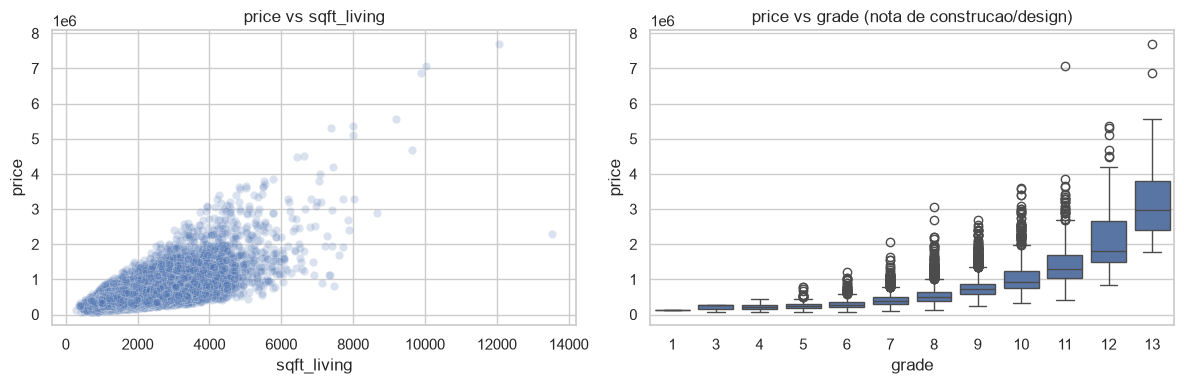

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.2, ax=axes[0])
axes[0].set_title("price vs sqft_living")

sns.boxplot(data=df, x="grade", y="price", ax=axes[1])
axes[1].set_title("price vs grade (nota de construcao/design)")
plt.tight_layout()
plt.show()

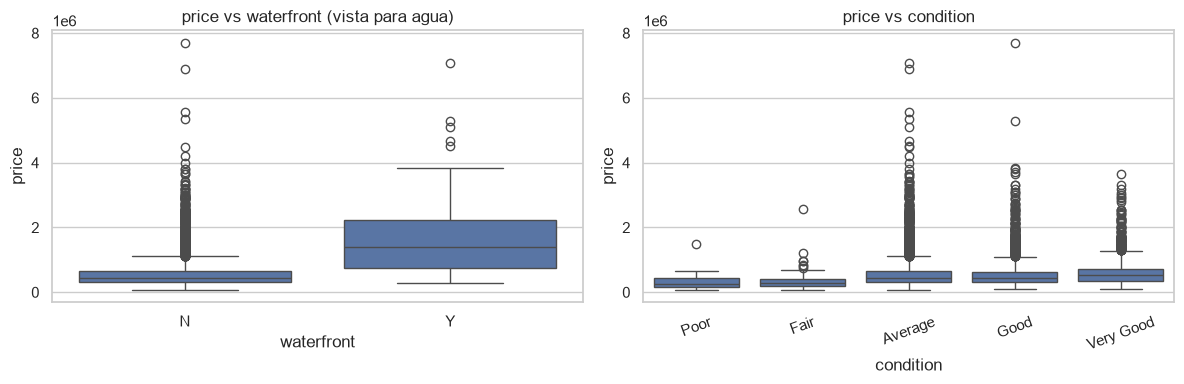

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="waterfront", y="price", ax=axes[0])
axes[0].set_title("price vs waterfront (vista para agua)")

order = ["Poor", "Fair", "Average", "Good", "Very Good"]
sns.boxplot(data=df, x="condition", y="price", order=order, ax=axes[1])
axes[1].set_title("price vs condition")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

`sqft_living` e `grade` mostram relacao forte e monotonica com o preco - bons
sinais para qualquer modelo. `waterfront` tem efeito grande (imoveis com vista para
agua sao visivelmente mais caros) apesar de ser raro (poucos imoveis = `Y`).
`condition` tem um efeito mais fraco e nao totalmente monotonico - por isso vale a
pena tratar como variavel ordinal (nao apenas categorica) no pipeline, preservando a
nocao de ordem Poor < Fair < Average < Good < Very Good.

## 5. Efeito geografico: `lat`/`long` e `zipcode`

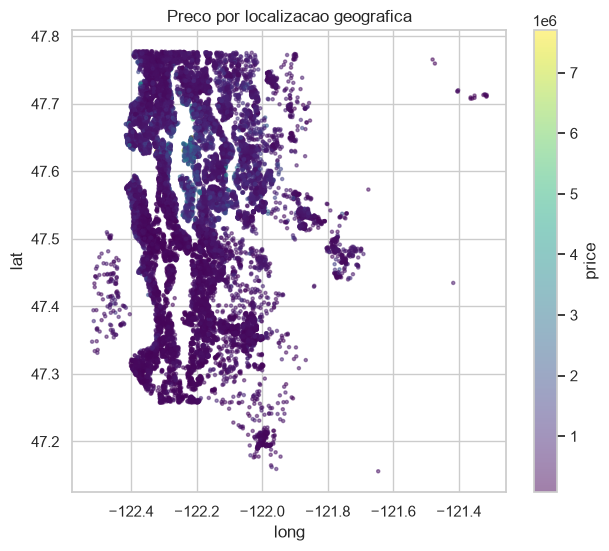

Zipcodes distintos: 70


In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(df["long"], df["lat"], c=df["price"], cmap="viridis", s=5, alpha=0.5)
plt.colorbar(sc, label="price")
ax.set_xlabel("long")
ax.set_ylabel("lat")
ax.set_title("Preco por localizacao geografica")
plt.show()

print("Zipcodes distintos:", df["zipcode"].nunique())

Ha um padrao geografico claro (regioes proximas ao centro/agua sao mais caras) -
`lat`/`long` sao features numericas uteis por si so. `zipcode` tem 70 valores
distintos: numericamente ele nao tem ordem real (98115 nao e "maior" que 98001 no
sentido de preco), entao ele entra no pipeline via one-hot encoding, nao como
numero cru.

## 6. Correlacoes entre features numericas

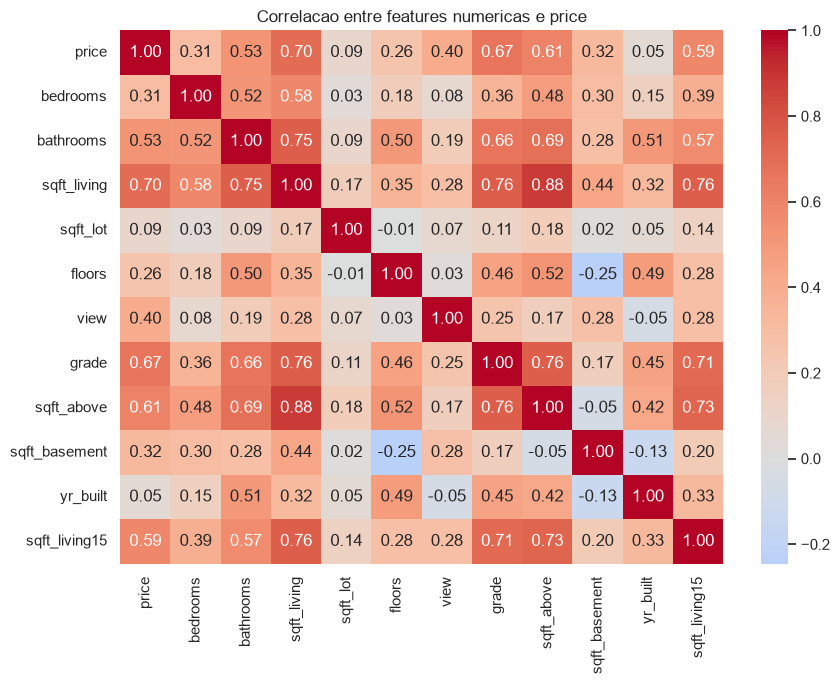

In [10]:
numeric_cols = [
    "price", "bedrooms", "bathrooms", "sqft_living", "sqft_lot", "floors",
    "view", "grade", "sqft_above", "sqft_basement", "yr_built", "sqft_living15",
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlacao entre features numericas e price")
plt.tight_layout()
plt.show()

`sqft_living` e a feature com maior correlacao linear com `price`, seguida de
`grade` e `sqft_above`. `sqft_living` e `sqft_above` sao fortemente correlacionadas
entre si (multicolinearidade esperada: area util total inclui a area acima do
solo) - para um modelo de arvore isso nao e um problema (arvores lidam bem com
features redundantes), entao mantemos ambas.

## 7. Resumo das decisoes de limpeza (-> `src/house_prices/data/clean.py`)

1. Deduplicar por `id`, mantendo a venda mais recente (evita vazamento de dados).
2. Remover outliers de `bedrooms` (> 15) - erro de digitacao conhecido.
3. Converter `date` em `sale_year` e descartar a string original.
4. Descartar `id` (nao e feature, so serve para deduplicar).

## Proximo passo

Ver `notebooks/02_modeling.ipynb` para a comparacao de modelos e a analise de
importancia de features, ou `src/house_prices/train.py` para o pipeline de
treino "de producao" que resulta dessas decisoes.